In [1]:

# Step 1: Handle Missing Values

import pandas as pd
from sklearn.impute import SimpleImputer

# Load the data (replace with your actual file path if needed)
train_df = pd.read_csv("Train_heart_disease_uci.csv")
test_df = pd.read_csv("Test_heart_disease_uci.csv")

# Drop unnecessary columns
train_df.drop(columns=["id", "dataset"], inplace=True)
test_df.drop(columns=["id", "dataset"], inplace=True)

# Separate features and target
X_train = train_df.drop(columns=["num"])
y_train = train_df["num"]
X_test = test_df.copy()  # test set has no 'num' column

# Identify categorical and numerical columns
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Impute missing values for numerical columns with mean
num_imputer = SimpleImputer(strategy="mean")
X_train[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])

# Impute missing values for categorical columns with most frequent
cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Confirm no missing values left
print("Missing values in training set:\n", X_train.isnull().sum())
print("Missing values in test set:\n", X_test.isnull().sum())


Missing values in training set:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
Missing values in test set:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


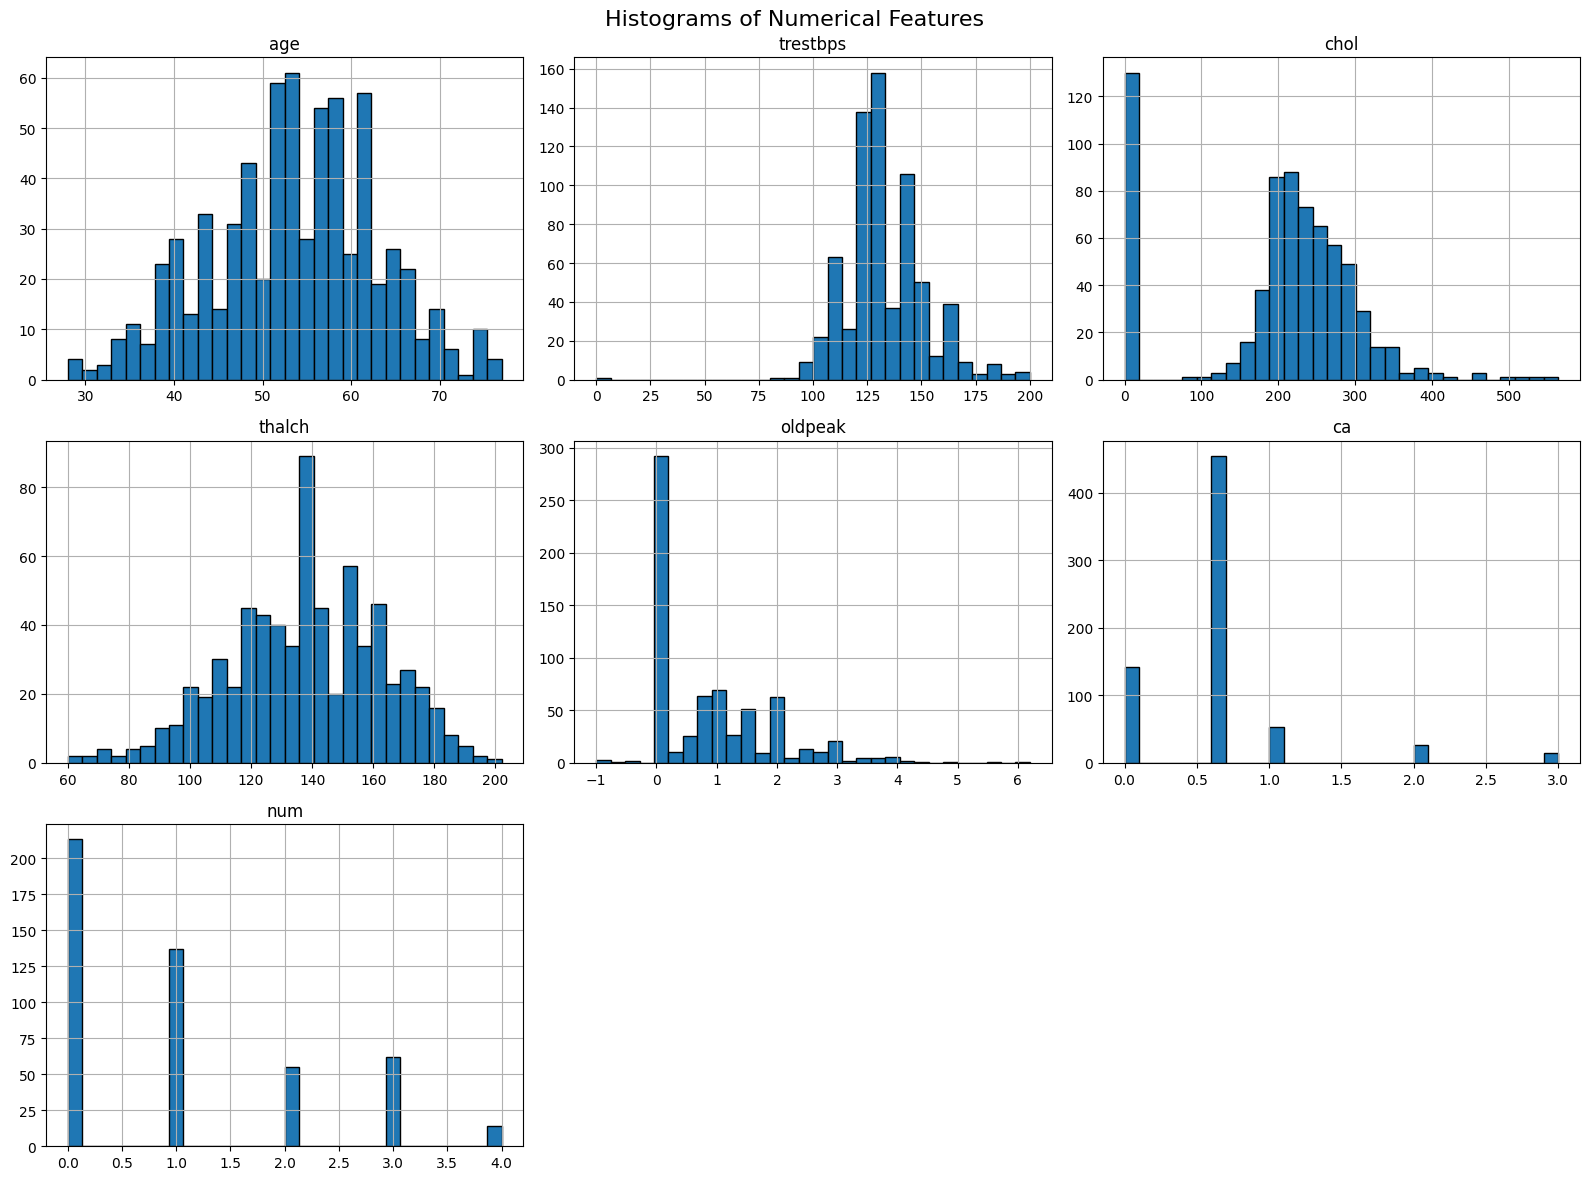

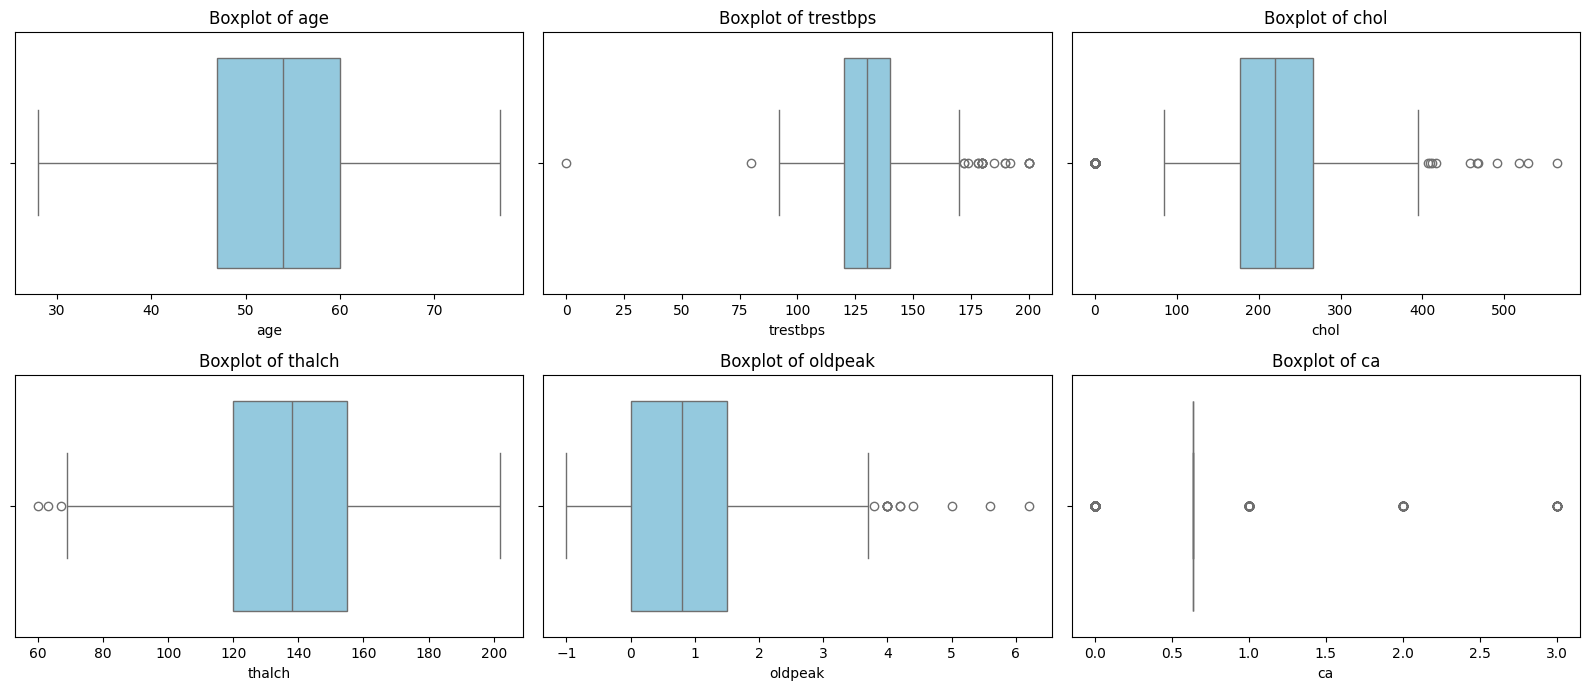

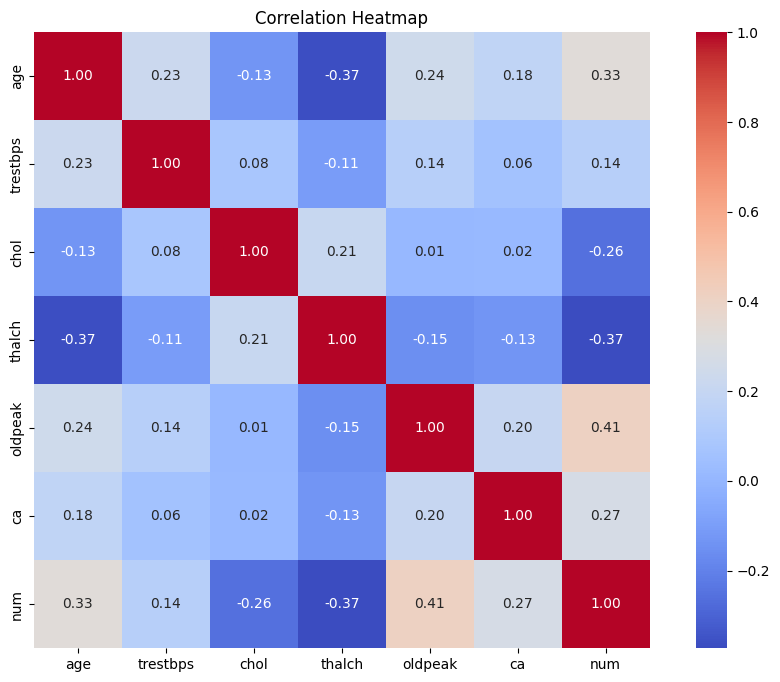

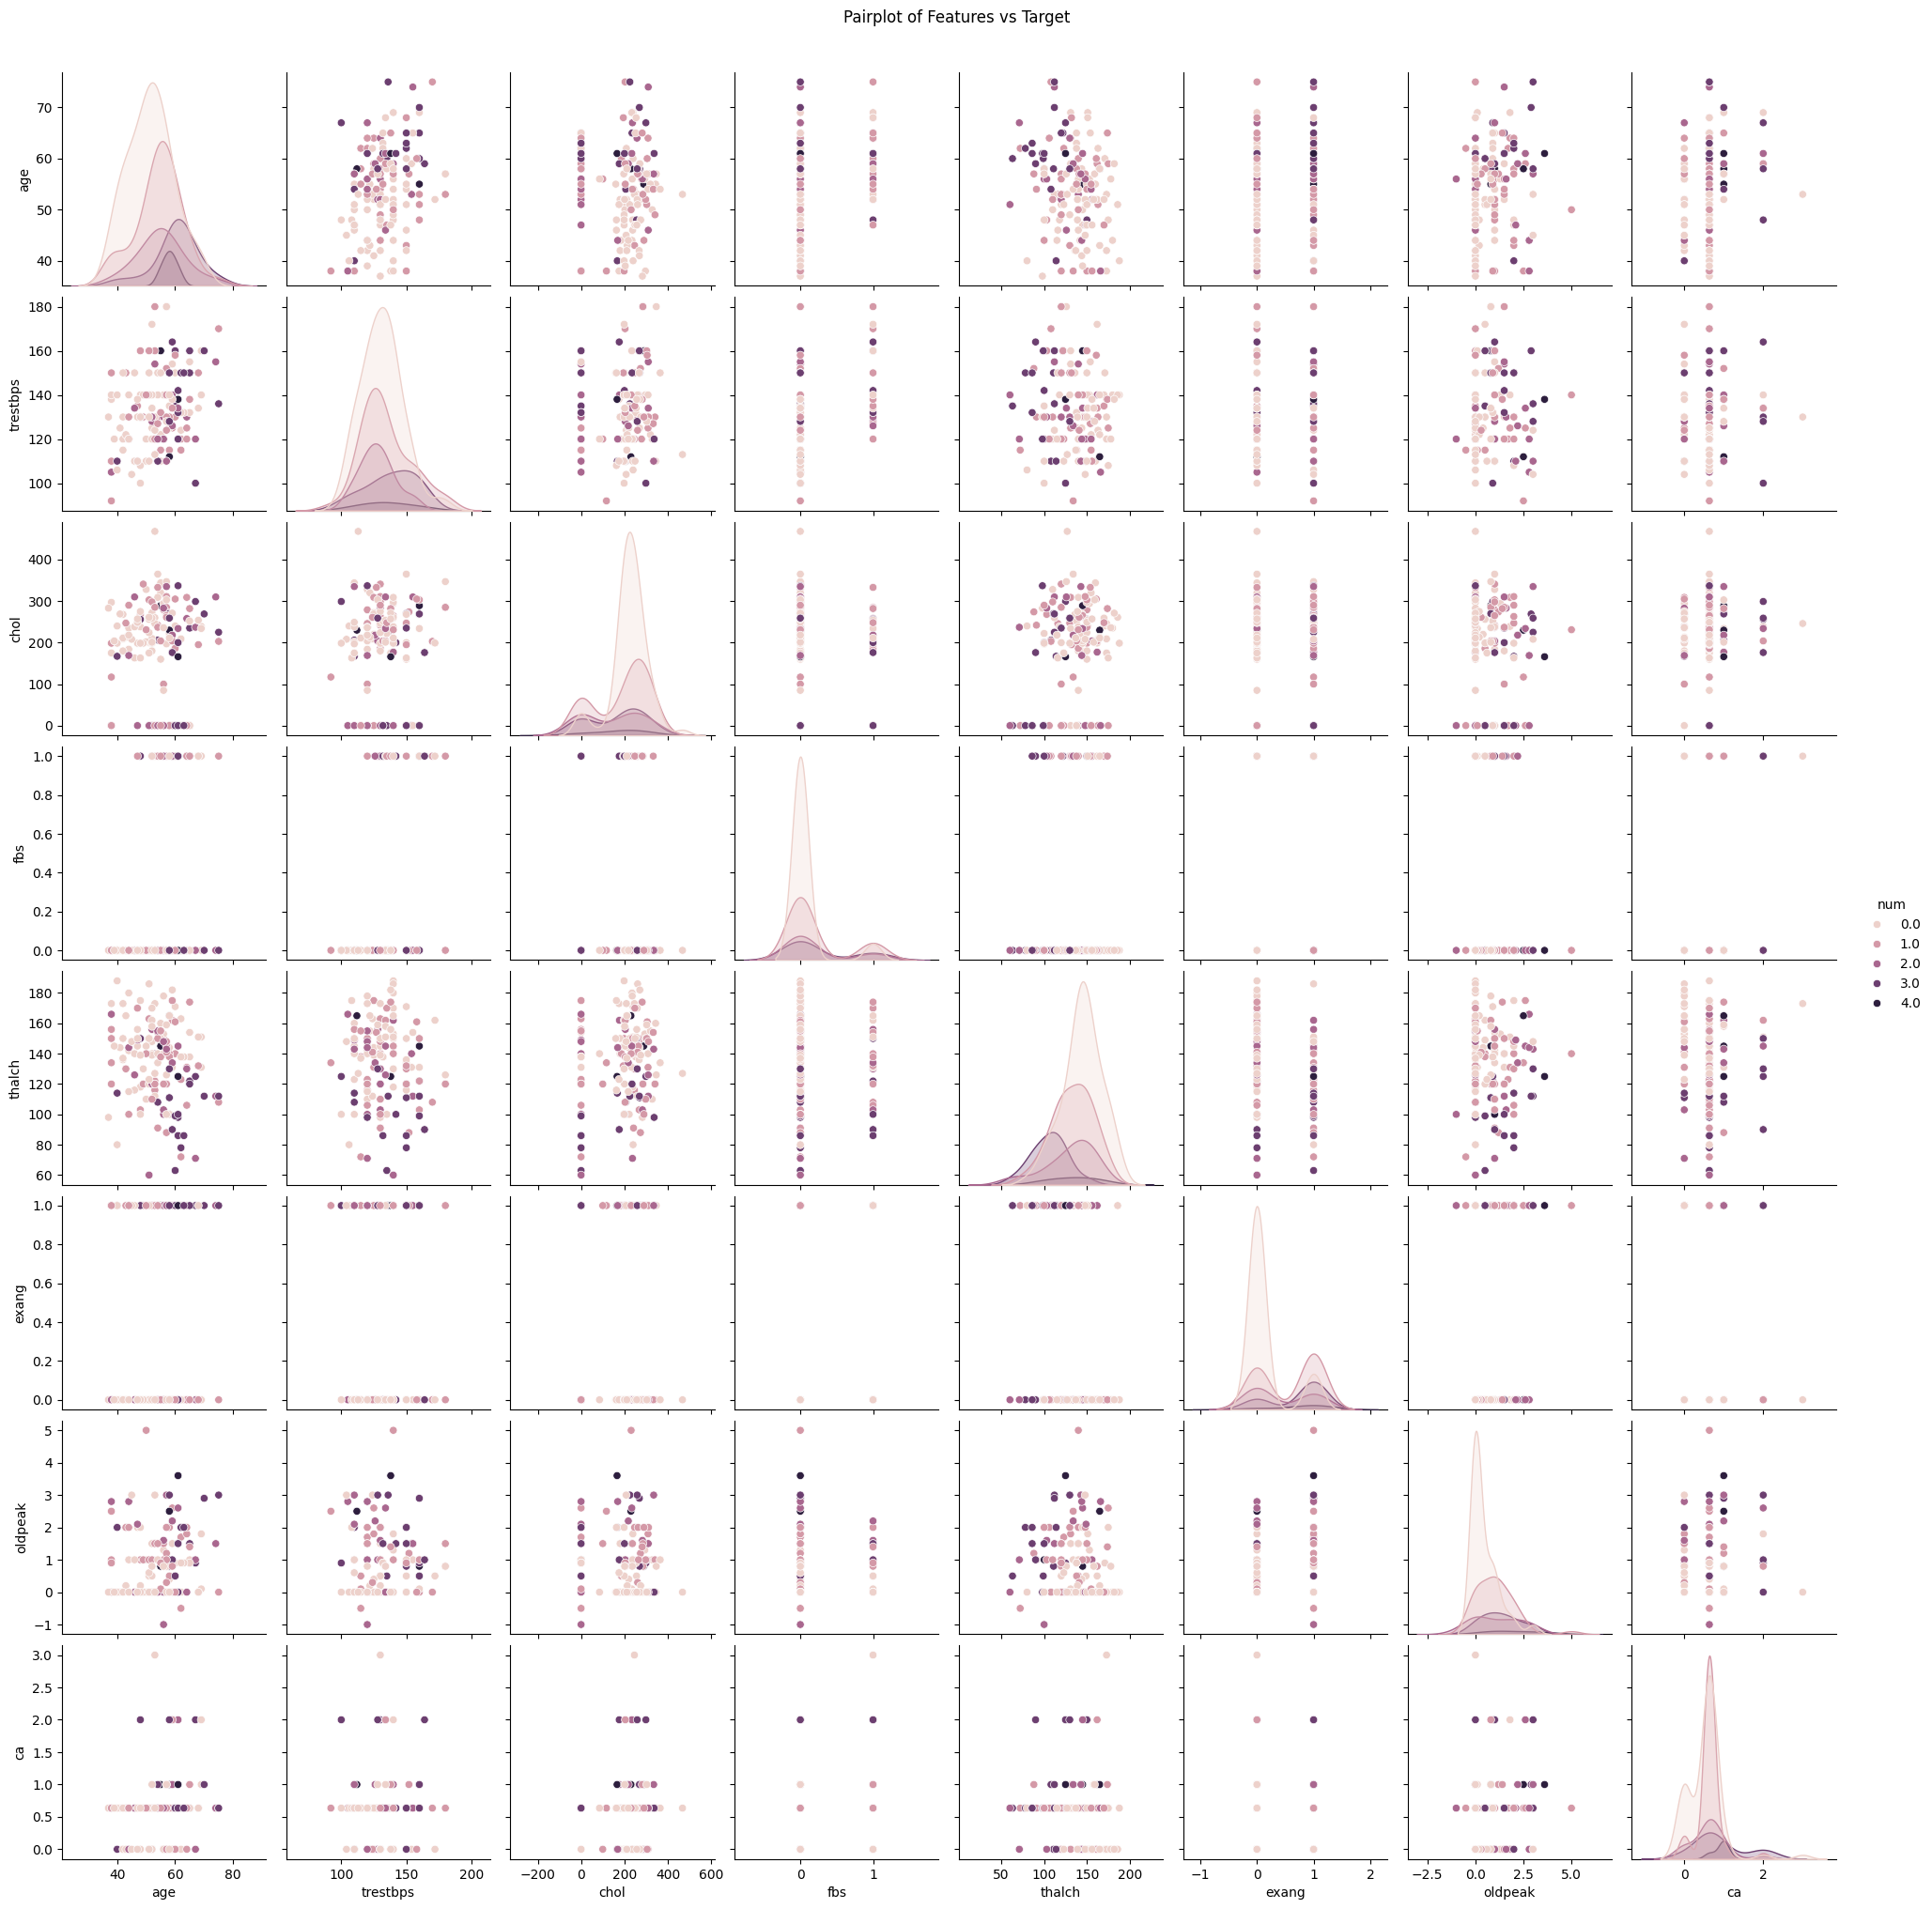

In [2]:


# Step 2: Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Combine features and target for easier visualization
visual_df = X_train.copy()
visual_df["num"] = y_train

# 1. Histograms for feature distributions
visual_df.hist(bins=30, figsize=(16, 12), edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

# 2. Boxplots for outlier detection
plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=visual_df[col], color="skyblue")
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = visual_df[numerical_cols + ["num"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

# 4. Pairplot (sampled to avoid slowdown)
sampled_df = visual_df.sample(200, random_state=42)  # reduce for performance
sns.pairplot(sampled_df, hue="num", diag_kind="kde")
plt.suptitle("Pairplot of Features vs Target", y=1.02)
plt.show()

In [5]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.4 MB/s eta 0:00:00


In [15]:
# ✅ STEP 3: Semi-Supervised Learning — Filling Missing Labels (Final Version)

from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import pairwise_distances_argmin_min
import skfuzzy as fuzz
import numpy as np
import pandas as pd

# Ensure combined dataset (features + target)
data_combined = X_train.copy()
data_combined["num"] = y_train

# Separate labeled and unlabeled data
labeled_data = data_combined[data_combined["num"].notnull()]
unlabeled_data = data_combined[data_combined["num"].isnull()]

X_labeled = labeled_data.drop("num", axis=1).astype(float)
y_labeled = labeled_data["num"]
X_unlabeled = unlabeled_data.drop("num", axis=1).astype(float)

# --- K-Means Clustering ---
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_labeled)

nearest_kmeans, _ = pairwise_distances_argmin_min(X_unlabeled, X_labeled)
y_kmeans_filled = y_labeled.iloc[nearest_kmeans].values

# --- Spectral Clustering ---
spectral = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
spectral.fit(X_labeled)

nearest_spectral, _ = pairwise_distances_argmin_min(X_unlabeled, X_labeled)
y_spectral_filled = y_labeled.iloc[nearest_spectral].values

# --- Fuzzy C-Means Clustering ---
X_labeled_np = X_labeled.to_numpy().T
X_unlabeled_np = X_unlabeled.to_numpy().T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_labeled_np, c=5, m=2, error=0.005, maxiter=1000, seed=42
)

u_unlabeled, _, _, _, _, _ = fuzz.cluster.cmeans_predict(
    X_unlabeled_np, cntr, m=2, error=0.005, maxiter=1000
)

nearest_fcm, _ = pairwise_distances_argmin_min(X_unlabeled, X_labeled)
y_fcm_filled = y_labeled.iloc[nearest_fcm].values

# --- Reconstruct datasets with filled labels ---
X_train_kmeans = pd.concat([X_labeled, X_unlabeled])
y_train_kmeans = pd.concat([y_labeled, pd.Series(y_kmeans_filled, index=X_unlabeled.index)])

X_train_spectral = pd.concat([X_labeled, X_unlabeled])
y_train_spectral = pd.concat([y_labeled, pd.Series(y_spectral_filled, index=X_unlabeled.index)])

X_train_fcm = pd.concat([X_labeled, X_unlabeled])
y_train_fcm = pd.concat([y_labeled, pd.Series(y_fcm_filled, index=X_unlabeled.index)])

# --- Confirm that missing labels are filled ---
print("✅ K-Means filled missing labels:", y_train_kmeans.isnull().sum(), "missing")
print("✅ Spectral filled missing labels:", y_train_spectral.isnull().sum(), "missing")
print("✅ Fuzzy C-Means filled missing labels:", y_train_fcm.isnull().sum(), "missing")

print("\n✅ All three clustering methods completed successfully!")

✅ K-Means filled missing labels: 0 missing
✅ Spectral filled missing labels: 0 missing
✅ Fuzzy C-Means filled missing labels: 0 missing

✅ All three clustering methods completed successfully!


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [16]:
# STEP 4: Classification Model Training — AdaBoost & Gradient Descent

from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score

# Choose the filled dataset you want to use
X_final = X_train_kmeans   # or X_train_spectral, X_train_fcm
y_final = y_train_kmeans   # use the matching y_

# Split into train and validation (optional step for better evaluation)
from sklearn.model_selection import train_test_split
X_train_split, X_val, y_train_split, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# --- 1. AdaBoost Classifier ---
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost.fit(X_train_split, y_train_split)
y_pred_ada = adaboost.predict(X_val)

print("🔹 AdaBoost Classifier Results:")
print("Accuracy:", accuracy_score(y_val, y_pred_ada))
print(classification_report(y_val, y_pred_ada))

# --- 2. Gradient Descent-based Model (SGDClassifier) ---
sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train_split, y_train_split)
y_pred_sgd = sgd.predict(X_val)

print("\n🔹 SGD Classifier Results:")
print("Accuracy:", accuracy_score(y_val, y_pred_sgd))
print(classification_report(y_val, y_pred_sgd))

🔹 AdaBoost Classifier Results:
Accuracy: 0.5652173913043478
              precision    recall  f1-score   support

         0.0       0.70      0.77      0.73        66
         1.0       0.41      0.50      0.45        34
         2.0       0.38      0.18      0.24        17
         3.0       0.40      0.46      0.43        13
         4.0       1.00      0.12      0.22         8

    accuracy                           0.57       138
   macro avg       0.58      0.41      0.42       138
weighted avg       0.58      0.57      0.55       138


🔹 SGD Classifier Results:
Accuracy: 0.5144927536231884
              precision    recall  f1-score   support

         0.0       0.53      1.00      0.69        66
         1.0       0.00      0.00      0.00        34
         2.0       0.00      0.00      0.00        17
         3.0       0.36      0.38      0.37        13
         4.0       0.00      0.00      0.00         8

    accuracy                           0.51       138
   macro avg   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:


# STEP 5: Model Comparison & Optimization

from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Choose which clustering dataset to use (KMeans, Spectral, or FCM)
X_final = X_train_kmeans
y_final = y_train_kmeans

# Split into training and validation
from sklearn.model_selection import train_test_split
X_train_split, X_val, y_train_split, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# --- AdaBoost Tuning ---
ada_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.5, 1.0, 1.5]
}

ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), ada_params, cv=5)
ada_grid.fit(X_train_split, y_train_split)

best_ada = ada_grid.best_estimator_
y_pred_ada = best_ada.predict(X_val)

# --- SGDClassifier Tuning ---
sgd_params = {
    "loss": ["log_loss", "hinge"],
    "alpha": [0.0001, 0.001, 0.01],
    "penalty": ["l2", "l1"]
}

sgd_grid = GridSearchCV(SGDClassifier(max_iter=1000, tol=1e-3, random_state=42), sgd_params, cv=5)
sgd_grid.fit(X_train_split, y_train_split)

best_sgd = sgd_grid.best_estimator_
y_pred_sgd = best_sgd.predict(X_val)

# --- Results ---
print("🔍 Best AdaBoost Params:", ada_grid.best_params_)
print("✅ AdaBoost Accuracy:", accuracy_score(y_val, y_pred_ada))
print(classification_report(y_val, y_pred_ada))

print("\n🔍 Best SGDClassifier Params:", sgd_grid.best_params_)
print("✅ SGD Accuracy:", accuracy_score(y_val, y_pred_sgd))
print(classification_report(y_val, y_pred_sgd))

🔍 Best AdaBoost Params: {'learning_rate': 0.5, 'n_estimators': 50}
✅ AdaBoost Accuracy: 0.5579710144927537
              precision    recall  f1-score   support

         0.0       0.68      0.80      0.74        66
         1.0       0.40      0.53      0.46        34
         2.0       0.33      0.18      0.23        17
         3.0       0.50      0.23      0.32        13
         4.0       0.00      0.00      0.00         8

    accuracy                           0.56       138
   macro avg       0.38      0.35      0.35       138
weighted avg       0.51      0.56      0.52       138


🔍 Best SGDClassifier Params: {'alpha': 0.0001, 'loss': 'log_loss', 'penalty': 'l1'}
✅ SGD Accuracy: 0.5289855072463768
              precision    recall  f1-score   support

         0.0       0.66      0.92      0.77        66
         1.0       0.33      0.18      0.23        34
         2.0       0.00      0.00      0.00        17
         3.0       0.22      0.46      0.30        13
         4.0 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [18]:


from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- Evaluation for AdaBoost ---
ada_accuracy = accuracy_score(y_val, y_pred_ada)
ada_mse = mean_squared_error(y_val, y_pred_ada)
ada_mae = mean_absolute_error(y_val, y_pred_ada)

print("📊 AdaBoost Evaluation")
print("Accuracy:", round(ada_accuracy * 100, 2), "%")
print("Mean Squared Error:", round(ada_mse, 3))
print("Mean Absolute Error:", round(ada_mae, 3))

# --- Evaluation for SGD ---
sgd_accuracy = accuracy_score(y_val, y_pred_sgd)
sgd_mse = mean_squared_error(y_val, y_pred_sgd)
sgd_mae = mean_absolute_error(y_val, y_pred_sgd)

print("\n📊 SGD Classifier Evaluation")
print("Accuracy:", round(sgd_accuracy * 100, 2), "%")
print("Mean Squared Error:", round(sgd_mse, 3))
print("Mean Absolute Error:", round(sgd_mae, 3))

📊 AdaBoost Evaluation
Accuracy: 55.8 %
Mean Squared Error: 1.42
Mean Absolute Error: 0.696

📊 SGD Classifier Evaluation
Accuracy: 52.9 %
Mean Squared Error: 1.768
Mean Absolute Error: 0.812
